# Primal (w-based)

Implementation of soft-margin SVM using hinge loss + gradient descent:

$$
\sum_{i=1}^{n} \max(0, 1 - y_i(w^T x_i + b)) + \lambda \|w\|^2
$$



## Derivations

### Case 1: Correct + outside margin

$$y_i(w^Tx_i + b) \geq 1$$
    
- Loss = 0
- Gradient = 0

### Case 2: Inside margin/misclassified
$$y_i(w^Tx_i + b) < 1$$

Differentiating:

**wrt w**:
    $$\frac{d}{dw}(1 - y_i(w^T x_i + b)) = -y_i x_i$$

**wrt b**:
    $$\frac{\partial}{\partial b}(1 - y_i(w^T x_i + b)) = -y_i$$


### Derivation of Regularization

$$ \frac{d}{dw} \lambda \|w\|^2 = 2\lambda w $$
$$ \frac{d}{db} = 0 $$


### Final Gradients
#### Gradient w.r.t. w

$$\frac{dL}{dw} = \begin{cases} 2\lambda w & \text{if } y_i(w^T x_i + b) \geq 1 \\ 2\lambda w - y_i x_i & \text{if } y_i(w^T x_i + b) < 1 \end{cases}$$

---

#### Gradient w.r.t. b

$$
\frac{\partial b}{\partial L} = \begin{cases} 
      0 & \text{if } y_i(w^T x_i + b) \geq 1 \\
      -y_i & \text{if } y_i(w^T x_i + b) < 1 
   \end{cases}
$$

### Step 1: Load Data

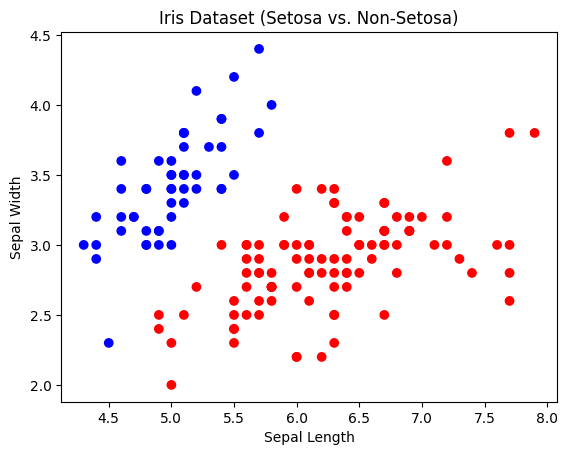

In [1]:
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

data = load_iris()
X = data.data[:, :2]
y = data.target

y = np.where(y == 0, -1, 1)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Iris Dataset (Setosa vs. Non-Setosa)')
plt.show()

### Step 2: Defining a SVM class

In [2]:
class SVM:
    def __init__(self, lr=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = lr
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Convert labels to {-1, 1}
        y_ = np.where(y <= 0, -1, 1)

        # Initialize parameters
        self.w = np.zeros(n_features)
        self.b = 0

        # GRADIENT DESCENT
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y_[idx] * (np.dot(x_i, self.w) + self.b) >= 1

                if condition:
                    # Only regularization term contribures
                    dw = 2 * self.lambda_param * self.w
                    db = 0

                else:
                    # Hinge loss contributes
                    dw = 2 * self.lambda_param * self.w - y_[idx] * x_i
                    db = -y_[idx]

                # Update parameters
                self.w -= self.lr * dw
                self.b -= self.lr * db

    def predict(self, X):
        approx = np.dot(X, self.w) + self.b
        
        # np.sign is a NumPy function that returns an element-wise indication of
        # the sign of a number, returning -1 if x < 0, 0 if x = 0 and 1 if x > 0
        return np.sign(approx)

### Step 3: Training SVM

In [3]:
# Train SVM
custom_model = SVM(lr=0.001, lambda_param=0.01, n_iters=1000)
custom_model.fit(X, y)

### Step 4: Making Predictions

In [4]:
# Predict
predictions = custom_model.predict(X)

print("Predictions: ", predictions)

Predictions:  [-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1.  1. -1. -1. -1. -1. -1. -1. -1. -1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.]


In [5]:
new_samples = np.array([[0, 0], [4, 4]])
predictions = custom_model.predict(new_samples)
print(predictions)

[-1. -1.]


### Visualization

In [6]:
def plot_decision_boundary(X, y, model, is_sklearn=False):
    plt.figure()

    # Plot data points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')

    # Create grid
    x0 = np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 100)
    x1 = np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 100)
    xx, yy = np.meshgrid(x0, x1)
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Get decision function values
    if is_sklearn:
        Z = model.decision_function(grid)

    else:
        Z = np.dot(grid, model.w) + model.b

    Z = Z.reshape(xx.shape)

    # Plot decision boundary (0)
    plt.contour(xx, yy, Z, levels=[0])

    # Plot margin lines
    plt.contour(xx, yy, Z, levels=[-1, 1], linestyles='dashed')

    plt.title('SVM Decision Boundary')
    plt.xlabel('Sepal Length')
    plt.ylabel('Sepal Width')
    plt.show()

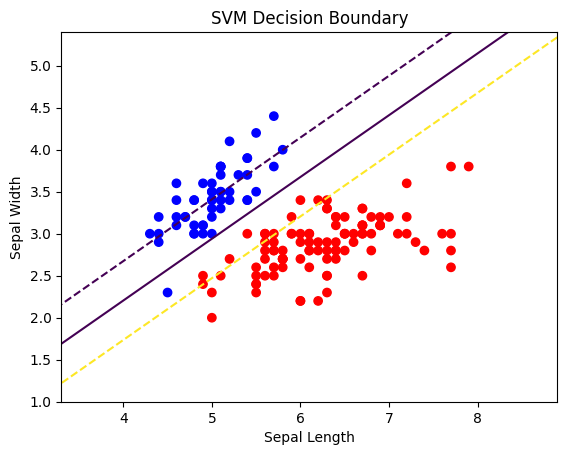

In [7]:
plot_decision_boundary(X, y, custom_model)

---

## Comparing with Scikit-Learn

In [8]:
from sklearn.svm import SVC

# Train SVM
sk_model = SVC(kernel='linear')
sk_model.fit(X, y)

# Predict
# predictions = model.predict(X)

new_samples = np.array([[0, 0], [4, 4]])
predictions = sk_model.predict(new_samples)
print(predictions)

[-1 -1]


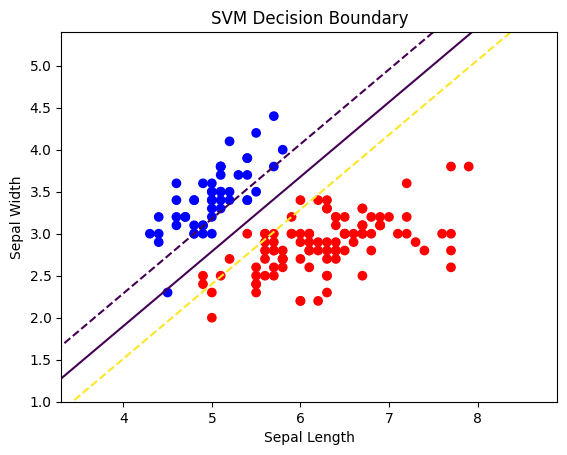

In [9]:
plot_decision_boundary(X, y, sk_model, is_sklearn=True)

---

# Kernel SVM

In [10]:
import numpy as np

def linear_kernel(x, z):
    return np.dot(x, z)

def polynomial_kernel(x, z, degree=3, c=1):
    return (np.dot(x, z) + c) ** degree

def rbf_kernel(x, z, gamma=0.1):
    return np.exp(-gamma * np.linalg.norm(x - z)**2)

In [27]:
class KernelSVM:
    def __init__(self, kernel=linear_kernel, C=1.0, lr=0.001, n_iters=1000):
        self.kernel = kernel
        self.C = C
        self.lr = lr
        self.n_iters = n_iters

    def fit(self, X, y):
        n_samples = X.shape[0]
        y_ = np.where(y <= 0, -1, 1)

        self.X = X
        self.y = y_
        self.alpha = np.zeros(n_samples)
        self.b = 0

        # Precompute kernel matrix
        self.K = np.zeros((n_samples, n_samples))
        for i in range(n_samples):
            for j in range(n_samples):
                self.K[i, j] = self.kernel(X[i], X[j])

        # Batch gradient descent
        for _ in range(self.n_iters):
            # Decision function for all points
            f = self.K @ (self.alpha * self.y) + self.b

            # Find points that violate the hinge-loss margin [y_i * f_i < 1]
            margin_violated = (self.y * f < 1)

            if (np.any(margin_violated)):
                # Gradient w.r.t alpha
                grad_alpha = -self.y * (margin_violated @ (self.y * self.K))

                # Gradient w.r.t. b
                grad_b = - np.sum(self.y[margin_violated])

                # Update all alphas and b at once [Gradient Descent]
                self.alpha -= self.lr * grad_alpha
                self.b -= self.lr * grad_b

                # Clip alphas to [0, C] to enforce soft margin (0 <= alpha_i <= C)
                # np.clip() - used to limit values in a NumPy array to a specified
                # minimum and maximum range
                self.alpha = np.clip(self.alpha, 0, self.C)
    
    def predict(self, X):
        y_pred = []
        for x in X:
            result = np.sum(self.alpha * self.y * np.array([self.kernel(x_i, x) for x_i in self.X])) + self.b
            y_pred.append(result)

        return np.array(y_pred)

In [28]:
# Train with RBF kernel
model = KernelSVM(kernel=rbf_kernel, C=1.0)
model.fit(X, y)

# Predict
preds = model.predict(X)
print(preds)

[-1.56589185 -0.4982613  -1.13742257 -1.75437506  0.33195144  0.83861795]


### Visualization

In [29]:
def plot_kernel_boundary(model, X, y):
    plt.figure()

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')

    x0 = np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 200)
    x1 = np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 200)
    xx, yy = np.meshgrid(x0, x1)
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    # Decision boundary
    plt.contour(xx, yy, Z, levels=[0])

    # Margins
    plt.contour(xx, yy, Z, levels=[-1, 1], linestyles='dashed')

    plt.title('Kernel SVM (RBF) Decision Boundary')
    plt.xlabel('Sepal Length')
    plt.ylabel('Sepal Width')
    plt.show()

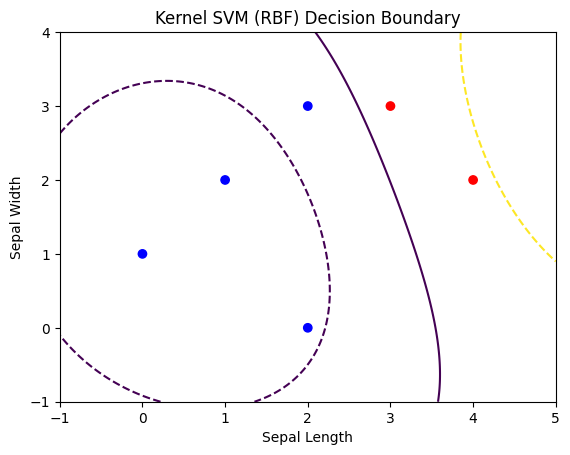

In [30]:
# Non-linear-ish dataset
X = np.array([
    [1, 2],
    [2, 3],
    [2, 0],
    [0, 1],
    [3, 3],
    [4, 2]
])
y = np.array([-1, -1, -1, -1, 1, 1])

model = KernelSVM(kernel=rbf_kernel, C=1.0)
model.fit(X, y)

plot_kernel_boundary(model, X, y)

### Code explained

Soft margin formula:
$$
\sum_{i=1}^{n} \max(0, 1 - y_i(w^T x_i + b)) + \lambda \|w\|^2
$$


Simplifies to: 
$$\max_{\alpha} \sum_{i=1}^{n} \alpha_i - \frac{1}{2} \sum_{i=1}^{n} \sum_{j=1}^{n} \alpha_i \alpha_j y_i y_j (x_i^T x_j)$$

subject to:
$$0 \le \alpha_i \le C, \quad \sum_{i=1}^{n} \alpha_i y_i = 0$$

#### Kernelized Dual SVM
If you replace the dot product with a kernel K($x_i, x_j$):

$$
\max_{\alpha} \sum_{i=1}^{n} \alpha_i - \frac{1}{2} \sum_{i=1}^{n} \sum_{j=1}^{n} \alpha_i \alpha_j y_i y_j K(x_i, x_j)
$$

subject to:
$$0 \le \alpha_i \le C, \quad \sum_{i=1}^{n} \alpha_i y_i = 0$$


#### Weight Vector in Dual Form (Representer Theorem)
$$w = \sum_{i=1}^{n} \alpha_i y_i \phi(x_i)$$


#### Decision function

The primal decision function is:
$$f(x) = w^T\phi(x) + b$$

Substitute $w = \sum_{i=1}^{n} \alpha_i y_i \phi(x_i) $:
$$f(x)=\left(\sum_{i=1}^n \alpha_i y_i \phi(x_i)\right)^T \phi(x)+b$$

Using the **Kernel Trick** ($K(x_i, x) = \phi(x_i)^T \phi(x)$):
$$f(x) = \sum_{i=1}^n \alpha_j y_j K(x_j, x_i) + b$$

- Only the points $\alpha_i > 0$ contribute -> these are the **support vectors**

**Predicted Class**:
$$
\text{sign}(f(x)) = 
\begin{cases} 
      +1 & f(x) > 0 \\
      -1 & f(x) < 0 
\end{cases}
$$